# Stage 2 The CAPM

Track A, Exhibits 2a-2d. Same 29-stock, 130-month cleaned inputs as Stage 1. Returns are already decimal units. Conventional OLS; no Holm adjustment or GRS test. See README.md for provenance and reproduction.

In [2]:
import pandas as pd
import numpy as np
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

stage2_dir = next((p for p in [Path.cwd(), Path.cwd()/"stage2", *Path.cwd().parents]
                  if (p/"data/returns_us_monthly.csv").is_file() and (p/"run_stage2.py").is_file()), None)
if stage2_dir is None:
    raise FileNotFoundError("Open the project root or stage2 folder in VS Code.")
returns = pd.read_csv(stage2_dir/"data/returns_us_monthly.csv", index_col="Month", float_precision="round_trip")
factors = pd.read_csv(stage2_dir/"data/ff3_monthly.csv", index_col="Month", float_precision="round_trip")
print("Stage 2 folder:", stage2_dir)
display(returns.head())
display(factors.head())


Stage 2 folder: /Users/annn/Desktop/FE5108-Group-Project-main/stage2


,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,XOM,GE,...,NKE,PFE,PG,TRV,RTX,UNH,VZ,V,WMT,DIS
Month,,,,,,,,,,,,,,,,,,,,,
2015-11,0.002537,-0.022113,-0.005804,-0.011621,-0.004658,0.017114,-0.055459,0.014094,-0.004450,0.035270,...,0.009540,-0.023226,-0.020162,0.014882,-0.017673,-0.043046,-0.030503,0.020263,0.027952,-0.002374
2015-12,-0.037936,-0.029174,-0.110228,-0.005913,-0.064556,-0.014893,-0.003303,0.007977,-0.045432,0.048196,...,-0.052744,-0.014953,0.061063,-0.009607,0.000209,0.048249,0.016942,-0.018479,0.050535,-0.068004
2016-01,0.002390,-0.227403,-0.075243,-0.169168,-0.072701,-0.038795,-0.117254,-0.000931,-0.001283,-0.065810,...,-0.007840,-0.055452,0.037678,-0.051568,-0.087228,-0.021081,0.094432,-0.039459,0.082545,-0.088123
2016-02,0.046380,0.038879,-0.001288,-0.007129,0.087725,-0.022802,0.100463,0.004893,0.038889,0.009391,...,-0.006773,-0.017111,-0.017138,0.004484,0.110051,0.034213,0.015209,-0.026274,-0.000301,-0.003131
2016-03,0.062217,0.104714,0.127211,0.074124,0.130576,0.143337,0.087471,0.083974,0.042920,0.090941,...,0.000625,-0.001011,0.025158,0.091503,0.036017,0.086750,0.066036,0.056500,0.040052,0.039678


,Mkt-RF,SMB,HML,RF
Month,,,,
2015-11,0.0057,0.0358,-0.0043,0.0000
2015-12,-0.0215,-0.0280,-0.0257,0.0001
2016-01,-0.0574,-0.0340,0.0208,0.0001
2016-02,-0.0006,0.0073,-0.0061,0.0002
2016-03,0.0695,0.0075,0.0123,0.0002


In [3]:
# Check dates, sample dimensions, missing values and numeric validity
assert returns.index.is_unique, "Duplicate months in stock returns"
assert factors.index.is_unique, "Duplicate months in factor data"
assert returns.index.equals(factors.index), "The two datasets have different months or ordering"

expected_months = pd.period_range(
    "2015-11", "2026-08", freq="M"
).astype(str)

assert returns.index.tolist() == expected_months.tolist(), "Sample months do not match the expected window"
assert returns.shape == (130, 29), "Stock returns must contain 130 months and 29 stocks"
assert {"RF", "Mkt-RF"}.issubset(factors.columns), "Required factor columns are missing"
assert np.isfinite(returns.to_numpy(dtype=float)).all(), "Stock returns contain missing or invalid values"
assert np.isfinite(factors.to_numpy(dtype=float)).all(), "Factors contain missing or invalid values"

# Subtract the contemporaneous risk-free return from each stock return
excess_returns = returns.sub(factors["RF"], axis=0)

# Mkt-RF is already the market excess return; use it directly
market_excess = factors["Mkt-RF"].copy()

print("Data checks passed")
print("Sample window:", returns.index[0], "to", returns.index[-1])
print("Number of months:", len(returns))
print("Number of stocks:", len(returns.columns))
print("Mean market excess return (monthly):", f"{market_excess.mean():.3%}")

display(excess_returns.head())

Data checks passed
Sample window: 2015-11 to 2026-08
Number of months: 130
Number of stocks: 29
Mean market excess return (monthly): 1.064%


,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,XOM,GE,GS,HD,INTC,IBM,JNJ,JPM,MCD,MRK,MSFT,NKE,PFE,PG,TRV,RTX,UNH,VZ,V,WMT,DIS
Month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-11,0.002537,-0.022113,-0.005804,-0.011621,-0.004658,0.017114,-0.055459,0.014094,-0.004450,0.035270,0.016911,0.082821,0.034109,0.004624,0.009465,0.037821,0.024989,-0.030187,0.039444,0.009540,-0.023226,-0.020162,0.014882,-0.017673,-0.043046,-0.030503,0.020263,0.027952,-0.002374
2015-12,-0.038036,-0.029274,-0.110328,-0.006013,-0.064656,-0.014993,-0.003403,0.007877,-0.045532,0.048096,-0.051621,-0.007903,-0.009303,-0.013010,0.014519,-0.009848,0.034764,0.004926,0.020691,-0.052844,-0.015053,0.060963,-0.009707,0.000109,0.048149,0.016842,-0.018579,0.050435,-0.068104
2016-01,0.002290,-0.227503,-0.075343,-0.169268,-0.072801,-0.038895,-0.117354,-0.001031,-0.001383,-0.065910,-0.103690,-0.049174,-0.099665,-0.093328,0.016645,-0.092949,0.047640,-0.040804,-0.007130,-0.007940,-0.055552,0.037578,-0.051668,-0.087328,-0.021181,0.094332,-0.039559,0.082445,-0.088223
2016-02,0.046180,0.038679,-0.001488,-0.007329,0.087525,-0.023002,0.100263,0.004693,0.038689,0.009191,-0.070640,-0.013241,-0.037903,0.060529,0.014473,-0.053982,-0.046267,-0.009278,-0.069989,-0.006973,-0.017311,-0.017338,0.004284,0.109851,0.034013,0.015009,-0.026474,-0.000501,-0.003331
2016-03,0.062017,0.104514,0.127011,0.073924,0.130376,0.143137,0.087271,0.083774,0.042720,0.090741,0.049623,0.080719,0.093075,0.155642,0.028219,0.051665,0.072247,0.062793,0.085295,0.000425,-0.001211,0.024958,0.091303,0.035817,0.086550,0.065836,0.056300,0.039852,0.039478


**2A**

In [4]:
# Dependent variable: AAPL monthly excess returns
y = excess_returns["AAPL"]

# Regressor: market excess returns, with an intercept
X = sm.add_constant(market_excess)

# Estimate the CAPM using conventional OLS standard errors
aapl_model = sm.OLS(y, X).fit()

# Display the main results
aapl_results = pd.DataFrame({
    "Stock": ["AAPL"],
    "Alpha (monthly)": [aapl_model.params["const"]],
    "Beta": [aapl_model.params["Mkt-RF"]],
    "t(Alpha)": [aapl_model.tvalues["const"]],
    "p(Alpha)": [aapl_model.pvalues["const"]],
    "R²": [aapl_model.rsquared],
    "Sample size": [int(aapl_model.nobs)]
})

display(
    aapl_results.style.format({
        "Alpha (monthly)": "{:.3%}",
        "Beta": "{:.4f}",
        "t(Alpha)": "{:.3f}",
        "p(Alpha)": "{:.4f}",
        "R²": "{:.3f}"
    })
)

,Stock,Alpha (monthly),Beta,t(Alpha),p(Alpha),R²,Sample size
0,AAPL,0.838%,1.1361,1.530,0.1286,0.416,130


In [5]:
# Use the same market excess return and intercept for all stocks
X = sm.add_constant(market_excess)

capm_models = {}
rows = []

for ticker in excess_returns.columns:
    model = sm.OLS(excess_returns[ticker], X).fit()
    capm_models[ticker] = model

    rows.append({
        "Ticker": ticker,
        "Alpha_monthly": model.params["const"],
        "Beta": model.params["Mkt-RF"],
        "t_Alpha": model.tvalues["const"],
        "p_Alpha": model.pvalues["const"],
        "R_squared": model.rsquared,
        "N": int(model.nobs)
    })

capm_results = pd.DataFrame(rows)

assert len(capm_results) == 29
assert capm_results["N"].eq(130).all()

# Save results; returns in CSV files remain in decimal units
results_dir = stage2_dir / "results"
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / "capm_results.csv"
capm_results.to_csv(output_path, index=False)

# Format the notebook output for readability
display(
    capm_results.style.format({
        "Alpha_monthly": "{:.3%}",
        "Beta": "{:.4f}",
        "t_Alpha": "{:.3f}",
        "p_Alpha": "{:.4f}",
        "R_squared": "{:.3f}"
    })
)

print("Saved:", output_path)
print(
    "Number of stocks with alpha significant at 5%, without multiple-testing adjustment:",
    int((capm_results["p_Alpha"] < 0.05).sum())
)

Saved: /Users/annn/.codex/.chatgpt-projects/g-p-6ac74676c9a08191b80389271869f430/stage2/results/capm_results.csv
Number of stocks with alpha significant at 5%, without multiple-testing adjustment: 3


,Ticker,Alpha_monthly,Beta,t_Alpha,p_Alpha,R_squared,N
0,MMM,-0.460%,0.9239,-0.928,0.3550,0.366,130
1,AXP,0.119%,1.1913,0.249,0.8035,0.510,130
2,AAPL,0.838%,1.1361,1.530,0.1286,0.416,130
3,BA,-0.680%,1.3889,-0.819,0.4140,0.317,130
4,CAT,0.966%,1.2400,1.459,0.1470,0.368,130
5,CVX,0.202%,0.8682,0.319,0.7502,0.238,130
6,CSCO,0.361%,0.9328,0.695,0.4884,0.349,130
7,KO,0.322%,0.4088,0.842,0.4015,0.159,130
8,XOM,0.231%,0.7267,0.352,0.7255,0.169,130
9,GE,-0.107%,1.1667,-0.134,0.8940,0.259,130


**2B**

Cross-sectional R squared: 0.133
Figure saved: /Users/annn/.codex/.chatgpt-projects/g-p-6ac74676c9a08191b80389271869f430/stage2/figures/empirical_sml.png


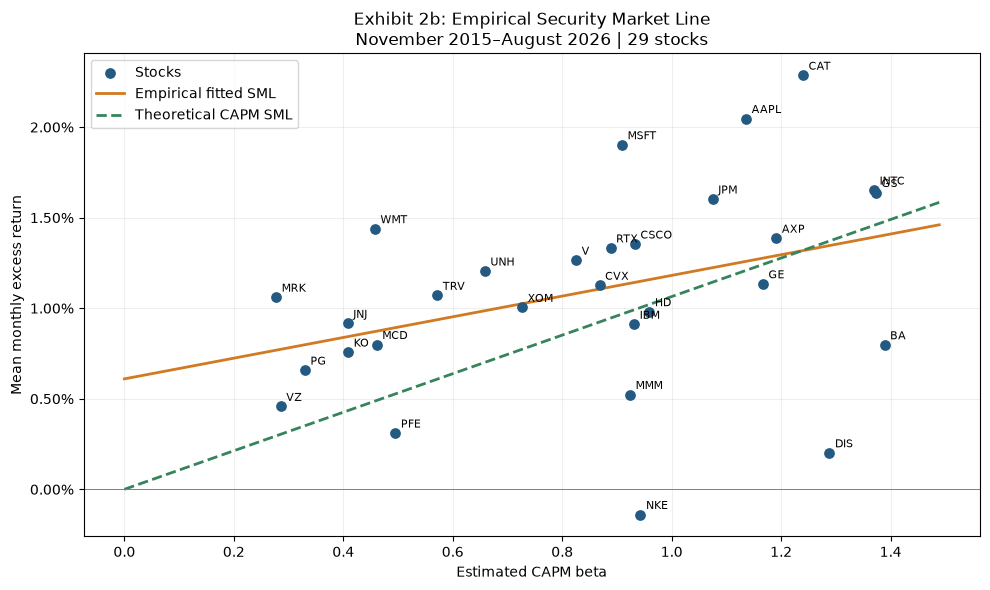

,Line,Intercept,Slope
0,Empirical fitted SML,0.610%,0.571%
1,Theoretical CAPM SML,0.000%,1.064%


In [6]:
from matplotlib.ticker import PercentFormatter

# 1. Match beta and mean monthly excess return by ticker
sml_points = capm_results[["Ticker", "Beta"]].copy()

sml_points["Mean_excess_return"] = sml_points["Ticker"].map(
    excess_returns.mean()
)

assert len(sml_points) == 29
assert not sml_points.isna().any().any()

# 2. Cross-sectional regression:
# Mean excess return = intercept + slope x beta
sml_X = sm.add_constant(sml_points["Beta"])
sml_model = sm.OLS(
    sml_points["Mean_excess_return"], sml_X
).fit()

sml_intercept = sml_model.params["const"]
sml_slope = sml_model.params["Beta"]
theoretical_slope = market_excess.mean()

# 3. Save the scatter data and fitted parameters for Exhibit 2d and the report
sml_summary = pd.DataFrame({
    "Line": ["Empirical fitted SML", "Theoretical CAPM SML"],
    "Intercept": [sml_intercept, 0.0],
    "Slope": [sml_slope, theoretical_slope]
})

results_dir = stage2_dir / "results"
figures_dir = stage2_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

sml_points.to_csv(results_dir / "sml_points.csv", index=False)
sml_summary.to_csv(results_dir / "sml_summary.csv", index=False)

# 4. Plot the empirical SML
beta_grid = np.linspace(
    min(0.0, sml_points["Beta"].min() - 0.1),
    sml_points["Beta"].max() + 0.1,
    300
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    sml_points["Beta"],
    sml_points["Mean_excess_return"],
    color="#245A81",
    s=45,
    zorder=3,
    label="Stocks"
)

ax.plot(
    beta_grid,
    sml_intercept + sml_slope * beta_grid,
    color="#D17A22",
    linewidth=2,
    label="Empirical fitted SML"
)

ax.plot(
    beta_grid,
    theoretical_slope * beta_grid,
    color="#36845B",
    linestyle="--",
    linewidth=2,
    label="Theoretical CAPM SML"
)

# Label the stock tickers
for row in sml_points.itertuples(index=False):
    ax.annotate(
        row.Ticker,
        (row.Beta, row.Mean_excess_return),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.axhline(0, color="gray", linewidth=0.7)
ax.set_xlabel("Estimated CAPM beta")
ax.set_ylabel("Mean monthly excess return")
ax.set_title(
    "Exhibit 2b: Empirical Security Market Line\n"
    "November 2015–August 2026 | 29 stocks"
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()

figure_path = figures_dir / "empirical_sml.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

# 5. Display the parameters of both lines
display(
    sml_summary.style.format({
        "Intercept": "{:.3%}",
        "Slope": "{:.3%}"
    })
)

print("Cross-sectional R squared:", f"{sml_model.rsquared:.3f}")
print("Figure saved:", figure_path)

**2C**

In [7]:
# Exhibit 2c: significant alpha counts and chance significance
# Use the conventional OLS results from 2a; no Holm adjustment or GRS test

alpha_tests = capm_results.copy()

# Apply the criterion specified in the project handout
alpha_tests["Abs_t_Alpha"] = alpha_tests["t_Alpha"].abs()
alpha_tests["Abs_t_gt_2"] = alpha_tests["Abs_t_Alpha"] > 2

# Also retain the exact 5% p-value criterion to compare with the approximate rule
alpha_tests["p_lt_0_05"] = alpha_tests["p_Alpha"] < 0.05

n_assets = len(alpha_tests)
observed_count = int(alpha_tests["Abs_t_gt_2"].sum())

# |t| > 2 approximately corresponds to a two-sided 5% significance level
expected_count_approx = n_assets * 0.05

significant_assets = alpha_tests.loc[
    alpha_tests["Abs_t_gt_2"],
    ["Ticker", "Alpha_monthly", "t_Alpha", "p_Alpha"]
].copy()

significant_tickers = ", ".join(significant_assets["Ticker"])

alpha_assessment = pd.DataFrame([{
    "Number_of_assets": n_assets,
    "Criterion": "|t(Alpha)| > 2",
    "Observed_significant_count": observed_count,
    "Approx_expected_count_under_H0": expected_count_approx,
    "Significant_tickers": significant_tickers or "None"
}])

# Save the assessment without changing capm_results.csv
results_dir = stage2_dir / "results"
results_dir.mkdir(parents=True, exist_ok=True)

alpha_tests.to_csv(
    results_dir / "alpha_tests.csv", index=False
)

alpha_assessment.to_csv(
    results_dir / "alpha_assessment.csv", index=False
)

display(alpha_assessment)

display(
    significant_assets.style.format({
        "Alpha_monthly": "{:.3%}",
        "t_Alpha": "{:.3f}",
        "p_Alpha": "{:.4f}"
    })
)

print("Number of stocks:", n_assets)
print("Observed number with |t(Alpha)| > 2:", observed_count)
print(
    "Approximate expected number of chance significant results if all alphas are zero:",
    f"{expected_count_approx:.2f}"
)
print(
    "Number with exact p value < 0.05:",
    int(alpha_tests["p_lt_0_05"].sum())
)
print("Exhibit 2c results saved")

Number of stocks: 29
Observed number with |t(Alpha)| > 2: 3
Approximate expected number of chance significant results if all alphas are zero: 1.45
Number with exact p value < 0.05: 3
Exhibit 2c results saved


,Number_of_assets,Criterion,Observed_significant_count,Approx_expected_count_under_H0,Significant_tickers
0,29,|t(Alpha)| > 2,3,1.45,"MSFT, WMT, DIS"


,Ticker,Alpha_monthly,t_Alpha,p_Alpha
18,MSFT,0.935%,2.015,0.0460
27,WMT,0.952%,2.113,0.0366
28,DIS,-1.170%,-2.068,0.0406


**If all population alphas are zero, 29 tests at an approximate 5% level are expected to produce about 1.45 chance significant results. We observe three. This exceeds the expectation, but the expectation is not an upper bound. Stock tests may also be correlated, so the count comparison alone is insufficient to reject the joint null that all alphas are zero. No formal joint test is performed; the findings suggest possible pricing deviations rather than a definitive rejection of the CAPM.**

## 2D Fitted SML versus theory

In [8]:
# 2d: both lines use monthly excess returns.
sml_comparison = pd.DataFrame({
    "Parameter": ["Intercept", "Slope"],
    "Empirical_monthly": [sml_intercept, sml_slope],
    "Theory_monthly": [0.0, theoretical_slope]
})
sml_comparison["Difference_monthly"] = sml_comparison["Empirical_monthly"] - sml_comparison["Theory_monthly"]
sml_comparison.to_csv(stage2_dir/"results/sml_comparison.csv", index=False)
display(sml_comparison.style.format({c:"{:.3%}" for c in sml_comparison.columns if c != "Parameter"}))
print("Slope as fraction of theory:", f"{sml_slope/theoretical_slope:.1%}")
print("Fitted line crossing beta:", f"{sml_intercept/(theoretical_slope-sml_slope):.3f}")
print("Cross-sectional R squared:", f"{sml_model.rsquared:.3f}")
pricing_deviations = sml_points.copy()
pricing_deviations["CAPM_predicted_excess_return"] = pricing_deviations.Beta*theoretical_slope
pricing_deviations["Deviation_from_CAPM"] = pricing_deviations.Mean_excess_return-pricing_deviations.CAPM_predicted_excess_return
assert np.allclose(pricing_deviations.Deviation_from_CAPM, capm_results.Alpha_monthly)
pricing_deviations.to_csv(stage2_dir/"results/pricing_deviations.csv", index=False)


Slope as fraction of theory: 53.7%
Fitted line crossing beta: 1.237
Cross-sectional R squared: 0.133


,Parameter,Empirical_monthly,Theory_monthly,Difference_monthly
0,Intercept,0.610%,0.000%,0.610%
1,Slope,0.571%,1.064%,-0.493%


The fitted SML is **mean excess return = 0.610% + 0.571% × beta** per month, compared with **1.064% × beta** under the sample CAPM benchmark. Its slope is 53.7% of theory (46.3% flatter); its intercept exceeds the theoretical zero by 0.610 percentage points per month. The fitted lines cross at beta 1.237: below this level the empirical fit is above theory, and above it the fit is below theory. This describes the fitted relationship, not every individual stock.

The positive intercept is an extrapolation to beta zero because observed betas range from 0.277 to 1.389. It is not the risk-free rate or a demonstrated tradable zero-beta portfolio. Cross-sectional R squared is 0.133, distinct from the time-series R squared values in 2a. These are descriptive sample comparisons, not formal tests of SML parameter restrictions. Beta estimates and realized means are noisy; conventional alpha tests have their own assumptions. Missing factors and market-proxy limitations remain possible explanations (Week 4, slides 34-35). Stage 3 examines factors, and Stage 4 changes the market proxy.


## Reproduction entry point

In [9]:
# Re-run the packaged entry point to verify and export the complete set of exhibits.
import runpy
runpy.run_path(str(stage2_dir/"run_stage2.py"), run_name="__main__")


Ticker  Alpha_monthly     Beta   t_Alpha  p_Alpha  R_squared   N
   MMM      -0.004599 0.923947 -0.928377 0.354959   0.365935 130
   AXP       0.001186 1.191255  0.249288 0.803537   0.509847 130
  AAPL       0.008381 1.136061  1.529512 0.128605   0.416337 130
    BA      -0.006804 1.388881 -0.819484 0.414033   0.317108 130
   CAT       0.009664 1.239989  1.459148 0.146974   0.367750 130
   CVX       0.002022 0.868232  0.319120 0.750156   0.237619 130
  CSCO       0.003610 0.932768  0.694915 0.488368   0.348539 130
    KO       0.003223 0.408819  0.841688 0.401532   0.159068 130
   XOM       0.002307 0.726705  0.351881 0.725506   0.169296 130
    GE      -0.001072 1.166700 -0.133530 0.893984   0.259493 130
    GS       0.001769 1.373171  0.359582 0.719752   0.563813 130
    HD      -0.000403 0.959205 -0.091952 0.926880   0.442703 130
  INTC       0.001942 1.369676  0.159944 0.873177   0.174376 130
   IBM      -0.000802 0.931366 -0.132340 0.894923   0.281828 130
   JNJ       0.004820 0.4